In [1]:
import matplotlib.pyplot as plt
import numpy as np

class BasinOfAttraction():
  def __init__(self, f, df, root_list, tol=1.0e-9, max_iter=200):
    self.f = f
    self.df = df
    self.root_list = np.array(root_list, dtype=complex) # Storing as numpy array of complex numbers for consistency
    self.tol = tol
    self.max_iter = max_iter

  def newton(self, f, f1, x_n, tol, max_iter):
    for i in range(1, max_iter + 1):
      fx = f(x_n)
      if (abs(fx) < tol):
        return x_n, i
      fpx = f1(x_n)
      if (fpx == 0):
        raise ZeroDivisionError (f"Zero Derivative at x = {x_n}")
      x_n = x_n - (fx / fpx)
    return x_n, max_iter

  def plot_basin(self):
    width, height = 500, 500

    x = np.linspace(-2.0, 2.0, width)
    y = np.linspace(-2.0, 2.0, height)
    X, Y = np.meshgrid(x, y)

    Z = X + 1j * Y # Z = X + iY

    image = np.zeros(Z.shape, dtype=int)
    iters = np.zeros(Z.shape, dtype=int)

    for i in range(height):
      for j in range(width):
        z0 = Z[i, j]

        root, num_iter = self.newton(self.f, self.df, z0, self.tol, self.max_iter)

        distances = np.abs(self.root_list - root)
        root_index = np.argmin(distances)

        image[i, j] = root_index
        iters[i, j] = num_iter

    plt.figure(figsize=(7, 7))
    plt.imshow(image, cmap='jet', extent=[-2, 2, -2, 2])
    plt.title("Newton's Method Basin of Attraction Image")
    plt.axis('off')
    plt.show()

Create a basin on attraction image for the function f(x) = (x - 4) * (x + 1)

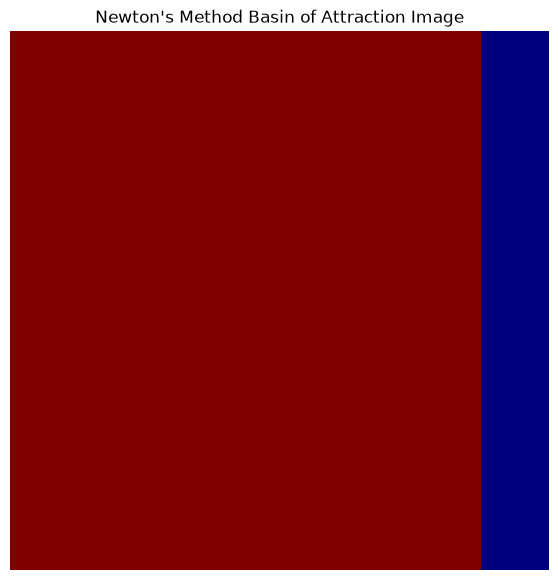

In [2]:
def f(x):
  return (x - 4) * (x + 1)

def df(x):
  return 2 * x - 3

roots = [4, -1]

basin = BasinOfAttraction(f, df, roots)
basin.plot_basin()

Create a basin on attraction image for the function g(x) = (x - 1) * (x + 3)

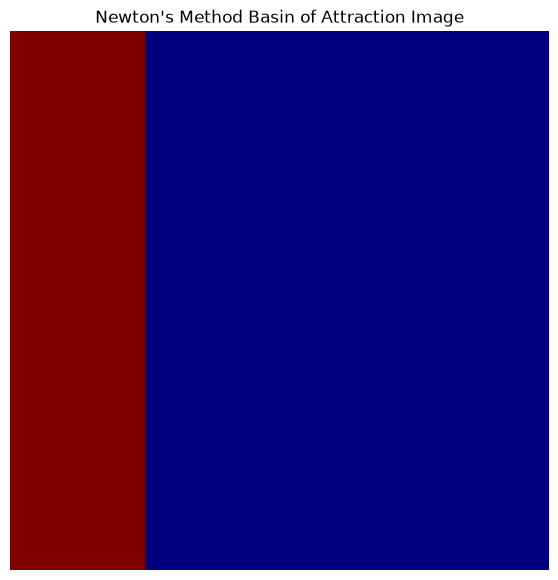

In [3]:
def f(x):
  return (x - 1) * (x + 3)

def df(x):
  return 2*x + 2

roots = [1, -3]

basin = BasinOfAttraction(f, df, roots)
basin.plot_basin()

Create a basin on attraction image for the function h(x) = (x - 4) * (x - 1) * (x + 3)

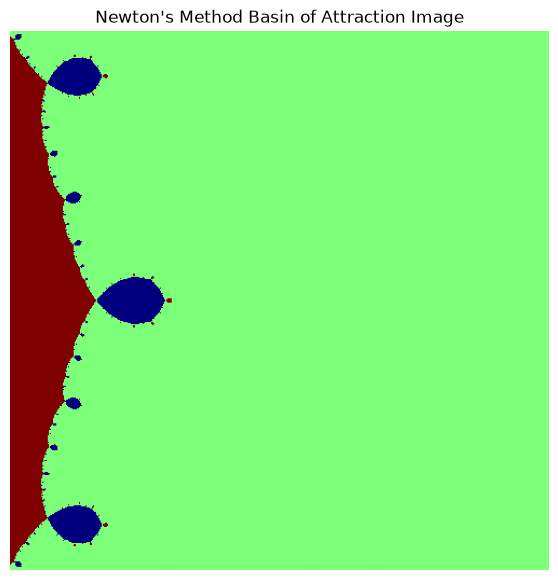

In [4]:
def f(x):
  return (x - 4) * (x - 1) * (x + 3)

def df(x):
  return 3*x**2 - 4*x - 11

roots = [4, 1, -3]

basin = BasinOfAttraction(f, df, roots)
basin.plot_basin()

Create a basin on attraction image for the function f(x) = x^3 - 2x - 5

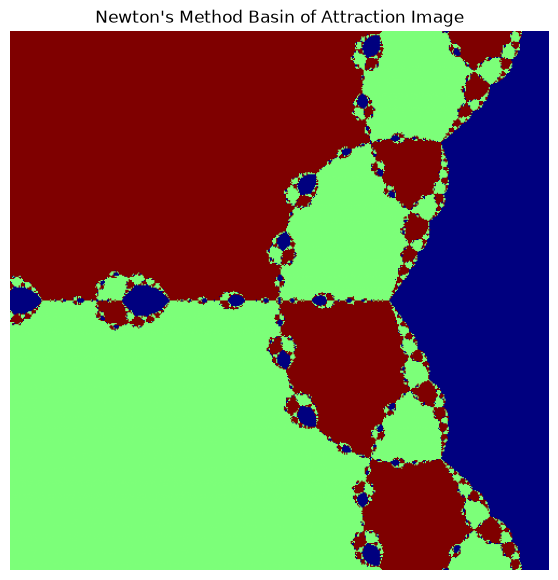

In [5]:
def f(x):
  return x**3 - 2*x - 5

def df(x):
  return 3*x**2 - 2

roots = [2.094551, -1.047276 + 1.135939j, -1.047276 - 1.135939j]

basin = BasinOfAttraction(f, df, roots)
basin.plot_basin()

In [ ]:
class BasinOfAttraction():
  def __init__(self, f, df, root_list, tol=1.0e-9, max_iter=200):
    self.f = f
    self.df = df
    self.root_list = np.array(root_list, dtype=complex) # Storing as numpy array of complex numbers for consistency
    self.tol = tol
    self.max_iter = max_iter

  def secant(self, f, x0, x1, tol, max_iter):
    for i in range(1, max_iter + 1):
      f0, f1 = f(x0), f(x1)
      if (abs(f1) < tol):
        return x1, i
      if (f1 - f0) == 0:
        raise ZeroDivisionError (f"Secant: f(x1) - f(x0) == 0")
      x2 = x1 - (f1 * (x1 - x0)) / (f1 - f0)
      x0, x1 = x1, x2
    return x1, max_iter

  def plot_basin(self):
    width, height = 500, 500

    x = np.linspace(-2.0, 2.0, width)
    y = np.linspace(-2.0, 2.0, height)
    X, Y = np.meshgrid(x, y)

    Z = X + 1j * Y # Z = X + iY

    image = np.zeros(Z.shape, dtype=int)
    iters = np.zeros(Z.shape, dtype=int)

    for i in range(height):
      for j in range(width):
        z0 = Z[i, j]

        z1 = z0 + 1e-6

        root, num_iter = self.secant(self.f, z0, z1, self.tol, self.max_iter)

        distances = np.abs(self.root_list - root)
        root_index = np.argmin(distances)

        image[i, j] = root_index
        iters[i, j] = num_iter

    plt.figure(figsize=(7, 7))
    plt.imshow(image, cmap='jet', extent=[-2, 2, -2, 2])
    plt.title("Secant Method Basin of Attraction Image")
    plt.axis('off')
    plt.show()

Use the Secant method on the function h(x) and determine the basins of attraction.

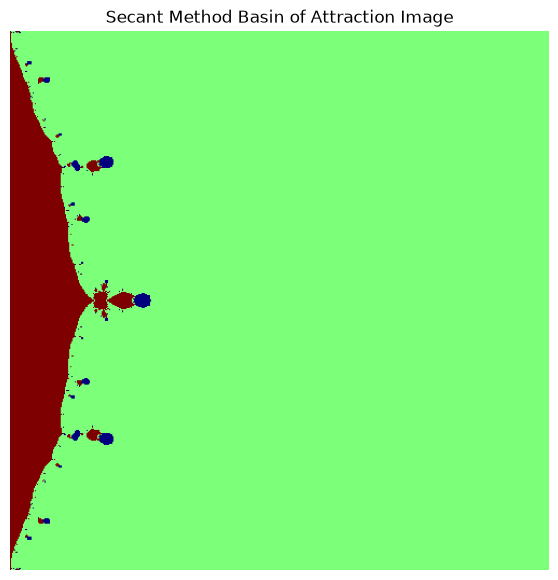

In [7]:
def f(x):
  return (x - 4) * (x - 1) * (x + 3)

def df(x):
  return 3*x**2 - 4*x - 11

roots = [4, 1, -3]

basin = BasinOfAttraction(f, df, roots)
basin.plot_basin()